In [1]:
!git clone https://github.com/Blackl1stV35/biosense-twr.git

Cloning into 'biosense-twr'...
remote: Enumerating objects: 61, done.
remote: Counting objects: 100% (61/61), done.
remote: Compressing objects: 100% (42/42), done.
remote: Total 61 (delta 16), reused 57 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (61/61), 240.95 KiB | 18.53 MiB/s, done.
Resolving deltas: 100% (16/16), done.


In [2]:
# ═══ CELL 1: Environment setup ═══
# pyo3 is a Rust crate — it is NOT a pip package and must not be pip-installed.
# maturin handles the Rust-Python bridge; only maturin is needed here.
import subprocess, sys, os

def run(cmd, env=None):
    """Run shell command, raise on failure, stream output."""
    result = subprocess.run(
        cmd, shell=True, check=True,
        executable='/bin/bash',          # needed for `source` to work
        env=env or os.environ.copy(),
        capture_output=False,
    )
    return result

# ── Rust toolchain ─────────────────────────────────────────────────────────
run('curl https://sh.rustup.rs -sSf | sh -s -- -y --default-toolchain stable --profile minimal')

# Persist cargo/rustc on PATH for all subsequent subprocess calls this session
os.environ['PATH'] = os.environ['PATH'] + ':/root/.cargo/bin'

# Verify
run('rustc --version && cargo --version')

# ── Python deps ─────────────────────────────────────────────────────────────
# maturin:     builds the PyO3 Rust extension (.so) and installs it as a Python module
# zstandard:   fast compression for checkpoint chunks
# NOT listed:  pyo3 — it is declared in Cargo.toml, compiled by maturin, not pip
run(
    'pip install -q '
    '"maturin>=1.4,<2.0" '
    'numpy scipy h5py tqdm pydantic '
    'zstandard '
    'google-auth google-auth-oauthlib google-api-python-client gdown'
)

# ── GPU check ────────────────────────────────────────────────────────────────
import shutil
if shutil.which('nvidia-smi') or os.path.exists('/usr/bin/nvidia-smi'):
    run('/usr/bin/nvidia-smi --query-gpu=name,memory.total --format=csv,noheader')
else:
    print('Warning: nvidia-smi not found — verify runtime is set to A100 GPU in Colab.')

print('\nEnvironment ready.')


Environment ready.


In [3]:
# ═══ CELL 2: Mount Drive + clone / sync repo ═══
from google.colab import drive
drive.mount('/content/drive')

import os
REPO_PATH   = '/content/biosense_twr'   # adjust to your repo path
DRIVE_ROOT  = '/content/drive/MyDrive/biosense_twr_poc'
DRIVE_FOLDER_ID = '1Wm1LV5lLNCyZ8xxYctm5Hk76YxsGeal2'  # TODO: fill in your Drive folder ID after creating it

os.makedirs(DRIVE_ROOT, exist_ok=True)

# If running from a cloned repo:
# !git clone https://github.com/Blackl1stV35/biosense-twr.git {REPO_PATH}
# For now assume repo already at REPO_PATH

import sys
sys.path.insert(0, f'{REPO_PATH}/poc')
print(f'Repo path: {REPO_PATH}')

Mounted at /content/drive
Repo path: /content/biosense_twr


In [4]:
# ═══ CELL 3: Build PyO3 Rust kernels with maturin ═══
import subprocess, os, glob, sys

REPO_PATH   = '/content/biosense-twr'   # Define REPO_PATH locally for robustness, corrected to use hyphen
RUST_DIR = f'{REPO_PATH}/poc'          # contains pyproject.toml
RUST_KERNELS_DIR = f'{REPO_PATH}/poc/rust_kernels'  # contains Cargo.toml

# Add cargo to PATH for this session
os.environ['PATH'] = os.environ['PATH'] + ':/root/.cargo/bin'

# --- Pre-build checks for debugging ---
print(f"Checking existence of RUST_DIR: {os.path.exists(RUST_DIR)}")
print(f"Checking existence of RUST_KERNELS_DIR: {os.path.exists(RUST_KERNELS_DIR)}")
cargo_toml_path = os.path.join(RUST_KERNELS_DIR, 'Cargo.toml')
print(f"Checking existence of Cargo.toml at {cargo_toml_path}: {os.path.exists(cargo_toml_path)}")

if not os.path.exists(RUST_DIR):
    raise FileNotFoundError(f"RUST_DIR not found: {RUST_DIR}. Please check your repository structure.")
if not os.path.exists(RUST_KERNELS_DIR):
    raise FileNotFoundError(f"RUST_KERNELS_DIR not found: {RUST_KERNELS_DIR}. Please check your repository structure.")
if not os.path.exists(cargo_toml_path):
    raise FileNotFoundError(f"Cargo.toml not found at: {cargo_toml_path}. Please check your repository structure.")

# Step 1: Build the Rust package into a wheel
print("Building Rust package with maturin...")
# Specify manifest-path to point to the correct Cargo.toml location
build_cmd = f'maturin build --release --manifest-path {cargo_toml_path}'
print(f"Running command: {build_cmd} in cwd: {RUST_DIR}")

result_build = subprocess.run(
    build_cmd, shell=True, cwd=RUST_DIR, # cwd remains RUST_DIR as it contains pyproject.toml
    capture_output=True, text=True
)

# Always print maturin's stdout and stderr for better debugging
print("\n--- Maturin Build Output ---")
print("STDOUT:")
print(result_build.stdout if result_build.stdout else '[No stdout]')
print("\nSTDERR:")
print(result_build.stderr if result_build.stderr else '[No stderr]')
print(f"\nMaturin exit code: {result_build.returncode}")
print("----------------------------\n")

if result_build.returncode != 0:
    raise RuntimeError(f'Rust build failed with exit code {result_build.returncode}. See output above.')

# After the build, check if the wheels directory exists before proceeding
# Correct the wheels_dir path to where maturin actually outputs the wheel
wheels_dir = os.path.join(RUST_KERNELS_DIR, 'target', 'wheels')
if not os.path.exists(wheels_dir):
    raise FileNotFoundError(f"Wheels directory not found after build: {wheels_dir}. Maturin build might have failed silently or not produced a wheel.")

# Step 2: Find the generated wheel file
wheel_path = None
# Maturin usually creates a target/wheels directory inside the cwd (RUST_DIR)
if os.path.exists(wheels_dir):
    # Assuming package name is 'biosense_twr' based on import statement
    wheel_files = glob.glob(os.path.join(wheels_dir, 'biosense_twr-*.whl'))
    if wheel_files:
        # Take the first one, usually there's only one relevant
        wheel_path = wheel_files[0]
        print(f"Found wheel: {wheel_path}")
    else:
        raise FileNotFoundError(f"No wheel file found in {wheels_dir} for biosense_twr")
else:
    raise FileNotFoundError(f"Wheels directory not found: {wheels_dir}")

# Step 3: Install the wheel using pip
if wheel_path:
    print(f"Installing wheel: {wheel_path}")
    install_cmd = f'pip install --force-reinstall {wheel_path}' # Use force-reinstall to ensure it's updated
    result_install = subprocess.run(
        install_cmd, shell=True,
        capture_output=True, text=True
    )
    print(result_install.stdout[-2000:] if result_install.stdout else '')
    if result_install.returncode != 0:
        print('STDERR:', result_install.stderr[-2000:])
        raise RuntimeError('Pip install of wheel failed')
    print("Rust kernels installed successfully.")
else:
    raise RuntimeError("Wheel path not determined, cannot install.")

# Verify import
from biosense_twr import rust_kernels
print('Rust kernels loaded:', dir(rust_kernels))

Checking existence of RUST_DIR: True
Checking existence of RUST_KERNELS_DIR: True
Checking existence of Cargo.toml at /content/biosense-twr/poc/rust_kernels/Cargo.toml: True
Building Rust package with maturin...
Running command: maturin build --release --manifest-path /content/biosense-twr/poc/rust_kernels/Cargo.toml in cwd: /content/biosense-twr/poc

--- Maturin Build Output ---
STDOUT:
[No stdout]

STDERR:
    Updating crates.io index
     Locking 52 packages to latest compatible versions
      Adding nalgebra v0.32.6 (available: v0.35.0)
      Adding ndarray v0.15.6 (available: v0.17.2)
      Adding numpy v0.21.0 (available: v0.29.0)
      Adding pyo3 v0.21.2 (available: v0.29.0)
  Downloaded approx v0.5.1
  Downloaded cfg-if v1.0.4
  Downloaded autocfg v1.5.1
  Downloaded paste v1.0.15
  Downloaded bytemuck v1.25.0
  Downloaded smallvec v1.15.2
  Downloaded scopeguard v1.2.0
  Downloaded wide v0.7.33
  Downloaded windows-link v0.2.1
  Downloaded typenum v1.20.1
  Downloaded uninden

In [5]:
# ═══ CELL 4: Config + checkpoint init ═══
import numpy as np
import torch
import time

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

# Simulation config
N_SCENARIOS_TOTAL = 2000    # total body pose scenarios to generate
CHUNK_SIZE        = 200     # flush to Drive every 200 scenarios
DURATION_S        = 3.0     # seconds of body motion per scenario
RUN_ID            = f'run_{int(time.time())}'

from biosense_twr.checkpoint_manager import CheckpointManager

ckpt = CheckpointManager(
    drive_folder_id=DRIVE_FOLDER_ID,
    run_id=RUN_ID,
    chunk_size=CHUNK_SIZE,
    compress_level=3,
)
ckpt.init_manifest(N_SCENARIOS_TOTAL)
start_from = ckpt.scenarios_already_done()
print(f'Starting from scenario {start_from}/{N_SCENARIOS_TOTAL}')
print(f'Drive budget remaining: {ckpt.budget_remaining_gb():.2f} GB')

Device: cuda
Starting from scenario 0/2000
Drive budget remaining: 4.50 GB


In [ ]:
from biosense_twr.simulation.wall_model     import WallConfig, MATERIAL_PARAMS
from biosense_twr.simulation.antenna_array  import MIMOArray
from biosense_twr.signal.boulic_model       import BoulicBody, ActivityType
from biosense_twr.signal.radar_echo         import RadarEchoConfig, synthesise_echo
from pathlib import Path

import collections
import torch.nn as nn

PosePred = collections.namedtuple('PosePred', ['confidence', 'coords'])

# BCEWithLogitsLoss for numerical stability under autocast
class PoseLoss(nn.Module):
    def __init__(self, alpha: float):
        super().__init__()
        self.bce   = nn.BCEWithLogitsLoss(reduction='mean')
        self.sl1   = nn.SmoothL1Loss(reduction='none')
        self.alpha = alpha

    def forward(self, pred: PosePred, gt_conf: torch.Tensor, gt_coords: torch.Tensor) -> torch.Tensor:
        loss_conf  = self.bce(pred.confidence, gt_conf)
        coord_err  = self.sl1(pred.coords, gt_coords)
        vis_mask   = gt_conf.unsqueeze(-1).expand_as(coord_err)
        loss_coord = (coord_err * vis_mask).mean()
        return loss_conf + self.alpha * loss_coord

from biosense_twr.inversion.pose_net import BioSensePoseNet, oks_metric

# Array geometry
array  = MIMOArray()
tx_pos = array.tx_positions()
rx_pos = array.rx_positions()

voxels = array.build_voxel_grid(resolution_m=0.10)
print(f'Voxel grid: {voxels.shape[:3]}  ({np.prod(voxels.shape[:3])} voxels)')

radar_cfg = RadarEchoConfig(mode='search', snr_db=15.0)
WALL_MATS = list(MATERIAL_PARAMS.keys())

# Pose network
input_shape = voxels.shape[:3]
model = BioSensePoseNet(input_shape=input_shape).to(DEVICE)

# P1 — Restore best weights from Drive if available.
# model_best.pt is saved from a torch.compile()-wrapped model, so state dict
# keys carry an '_orig_mod.' prefix. Strip it before loading into the bare model.
_best_model_path = Path(DRIVE_ROOT) / 'model_best.pt'
if _best_model_path.exists():
    _sd = torch.load(str(_best_model_path), map_location=DEVICE, weights_only=True)
    _sd = {k.removeprefix('_orig_mod.'): v for k, v in _sd.items()}
    model.load_state_dict(_sd)
    print(f'Restored weights from {_best_model_path}')
else:
    print('No saved model found — training from scratch.')

model     = torch.compile(model)
criterion = PoseLoss(alpha=1.0)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scaler    = torch.amp.GradScaler('cuda')

print('All components initialised.')

In [ ]:
from tqdm.auto import tqdm
import random

ACTIVITIES: list[ActivityType] = ['walk', 'run', 'crouch', 'stand', 'wave_arm']
rng = np.random.default_rng(seed=42 + start_from)

def scenario_to_radar_image(
    body: BoulicBody,
    wall: WallConfig,
    frame_idx: int,
    duration_s: float = DURATION_S,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Full PoC pipeline for one scenario frame:
      1. Generate body poses (Boulic model)
      2. Synthesise FM-UWB radar echo
      3. Apply wall correction (Rust kernel)
      4. Back-project 3D image (Rust kernel)
    Returns: (image (nx,ny,nz) f32, pose_gt (N_JOINTS,3) f32)
    """
    poses = body.generate_poses(duration_s)
    centres, rcs = body.poses_to_scatterers(poses)
    n_frames = poses.shape[0]
    fi = min(frame_idx, n_frames - 1)

    atten = 10 ** (-wall.total_attenuation_db(radar_cfg.fc) / 20.0)
    phase = wall.phase_shift_rad(radar_cfg.fc)

    s_raw = synthesise_echo(
        tx_pos, rx_pos,
        centres[fi], rcs,
        atten, phase, radar_cfg,
    )

    s_corr_r, s_corr_i = rust_kernels.apply_wall_correction(
        s_raw.real, s_raw.imag,
        wall.eps_r, wall.thickness_m, radar_cfg.fc, wall.attn_db_per_cm
    )

    image = rust_kernels.backproject_3d(
        s_corr_r, s_corr_i,
        tx_pos, rx_pos, voxels,
        float(radar_cfg.fs), float(radar_cfg.c0)
    )

    pose_gt = poses[fi].astype(np.float32)
    return image, pose_gt


# ── Training batch accumulation ──
BATCH_SIZE = 16
batch_images, batch_poses, batch_poses_raw, batch_confs = [], [], [], []
train_losses, oks_scores = [], []

# P1 — Restore best OKS baseline from Drive
_oks_log_path = Path(DRIVE_ROOT) / 'best_oks.txt'
best_oks_so_far = float(_oks_log_path.read_text()) if _oks_log_path.exists() else 0.0
print(f'Resuming with best OKS so far: {best_oks_so_far:.4f}')

pbar = tqdm(range(start_from, N_SCENARIOS_TOTAL), desc='Simulating')
for scenario_i in pbar:

    # ── Randomise scenario parameters ──
    activity  = random.choice(ACTIVITIES)
    mat       = random.choice(WALL_MATS)
    thickness = float(rng.uniform(0.10, 0.35))
    n_walls   = int(rng.choice([1, 2]))
    range_m   = float(rng.uniform(3.0, 25.0))
    height_m  = float(rng.uniform(1.55, 1.95))
    mass_kg   = float(rng.uniform(55, 100))

    wall = WallConfig(material=mat, thickness_m=thickness, num_walls=n_walls)
    body = BoulicBody(
        height_m=height_m, mass_kg=mass_kg, activity=activity,
        body_position=np.array([range_m, 0.0, 0.0], dtype=np.float32)
    )
    frame_idx = int(rng.integers(0, 100))

    # Range-gated voxel grid centred on body position
    voxels_scenario = array.build_voxel_grid(
        x_range=(-2.0, 2.0),
        y_range=(range_m - 3.0, range_m + 3.0),
        z_range=(-0.5, 2.5),
        resolution_m=0.10,
    )

    # ── Radar image ──
    image, pose_gt = scenario_to_radar_image(body, wall, frame_idx)
    pelvis      = pose_gt[0:1, :]
    pose_gt_raw = pose_gt.copy()
    scale       = float(np.linalg.norm(pose_gt[4] - pose_gt[0]) + 1e-6)
    pose_gt     = ((pose_gt - pelvis) / scale).astype(np.float32)
    image_norm  = image / (image.max() + 1e-9)

    conf_gt = np.ones(pose_gt.shape[0], dtype=np.float32)

    ckpt.add({
        'image':           image_norm.astype(np.float16),
        'pose_gt':         pose_gt,
        'scenario_params': np.array([range_m, thickness, n_walls, height_m, mass_kg], dtype=np.float32),
    })

    batch_images.append(torch.tensor(image_norm[None], dtype=torch.float32))
    batch_poses.append(torch.tensor(pose_gt))
    batch_poses_raw.append(pose_gt_raw)
    batch_confs.append(torch.tensor(conf_gt))

    if len(batch_images) == BATCH_SIZE:
        model.train()
        x  = torch.stack(batch_images).to(DEVICE)
        yp = torch.stack(batch_poses).to(DEVICE)
        yc = torch.stack(batch_confs).to(DEVICE)

        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            pred = model(x)
            loss = criterion(pred, yc, yp)
        scaler.scale(loss).backward()
        # P0 — gradient clipping to prevent loss spikes
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        with torch.no_grad():
            pred_denorm   = pred.coords.cpu().numpy() * scale + pelvis
            pred_denorm_t = torch.tensor(pred_denorm).to(DEVICE)
            gt_raw_t      = torch.tensor(np.stack([pose_gt_raw] * len(batch_poses_raw))).to(DEVICE)
            oks = oks_metric(pred_denorm_t, gt_raw_t, yc).item()

        train_losses.append(loss.item())
        oks_scores.append(oks)
        ckpt.update_best_oks(oks)

        # P2 — alpha scheduling
        if len(oks_scores) >= 10 and np.mean(oks_scores[-10:]) > 0.70:
            criterion.alpha = 5.0
        if len(oks_scores) >= 10 and np.mean(oks_scores[-10:]) > 0.85:
            criterion.alpha = 10.0

        # P1 — persist best model + OKS to Drive
        if oks > best_oks_so_far:
            best_oks_so_far = oks
            torch.save(model.state_dict(), Path(DRIVE_ROOT) / 'model_best.pt')
            Path(DRIVE_ROOT, 'best_oks.txt').write_text(str(best_oks_so_far))
            print(f'[Best model saved] OKS: {best_oks_so_far:.4f}')

        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'OKS': f'{oks:.4f}', 'alpha': f'{criterion.alpha:.0f}'})
        batch_images.clear(); batch_poses.clear(); batch_poses_raw.clear(); batch_confs.clear()

# Final flush
ckpt.flush(force=True)
print(f'\nSimulation complete. Best OKS: {max(oks_scores, default=0):.4f}')

# P3 — Two-wall stress test (inference only, no training)
# frame_idx uses a deterministic spread (10 + i*7) so each activity/range
# combination samples a genuinely different mid-motion pose, avoiding the
# degenerate t=0 case where all sin() terms are 0.
stress_scenarios = [
    {'mat': 'reinforced_concrete', 'n_walls': 2, 'thickness': 0.30,
     'range_m': r, 'activity': a, 'frame_idx': 10 + i * 7}
    for i, (r, a) in enumerate(
        (r, a)
        for r in [5.0, 10.0, 15.0, 20.0, 25.0]
        for a in ['walk', 'crouch', 'stand']
    )
]

print('\n─── Two-wall stress test (reinforced_concrete × 2, 15 scenarios) ───')
model.eval()
stress_oks_by_range: dict = {}

for sc in stress_scenarios:
    wall_s = WallConfig(material=sc['mat'], thickness_m=sc['thickness'], num_walls=sc['n_walls'])
    body_s = BoulicBody(
        height_m=1.75, mass_kg=75.0, activity=sc['activity'],
        body_position=np.array([sc['range_m'], 0.0, 0.0], dtype=np.float32),
    )
    image_s, pose_gt_s = scenario_to_radar_image(body_s, wall_s, frame_idx=sc['frame_idx'])
    pose_gt_raw_s = pose_gt_s.copy()
    pelvis_s      = pose_gt_s[0:1, :]
    scale_s       = float(np.linalg.norm(pose_gt_s[4] - pose_gt_s[0]) + 1e-6)
    image_norm_s  = image_s / (image_s.max() + 1e-9)

    x_s    = torch.tensor(image_norm_s[None, None], dtype=torch.float32).to(DEVICE)
    conf_s = torch.ones(1, pose_gt_raw_s.shape[0], dtype=torch.float32).to(DEVICE)

    with torch.no_grad():
        pred_s        = model(x_s)
        pred_denorm_s = pred_s.coords.cpu().numpy() * scale_s + pelvis_s
        pred_t        = torch.tensor(pred_denorm_s).to(DEVICE)
        gt_t          = torch.tensor(pose_gt_raw_s[None]).to(DEVICE)
        oks_s         = oks_metric(pred_t, gt_t, conf_s).item()

    stress_oks_by_range.setdefault(sc['range_m'], []).append(oks_s)

print(f'{"Range (m)":>10} | {"Mean OKS":>10} | {"Activities"}')
print('─' * 42)
for r in sorted(stress_oks_by_range):
    print(f'{r:>10.1f} | {np.mean(stress_oks_by_range[r]):>10.4f} | walk / crouch / stand')

In [15]:
# ═══ CELL 7: Save model to Drive ═══
import torch
from pathlib import Path

model_path = Path(DRIVE_ROOT) / 'model_latest.pt'
torch.save({
    'model_state':     model.state_dict(),
    'optimizer_state': optimizer.state_dict(),
    'best_oks':        max(oks_scores, default=0),
    'train_losses':    train_losses,
    'oks_scores':      oks_scores,
    'run_id':          RUN_ID,
}, str(model_path))

print(f'Model saved → {model_path} ({model_path.stat().st_size / 1024**2:.1f} MB)')

Model saved → /content/drive/MyDrive/biosense_twr_poc/model_latest.pt (5.3 MB)


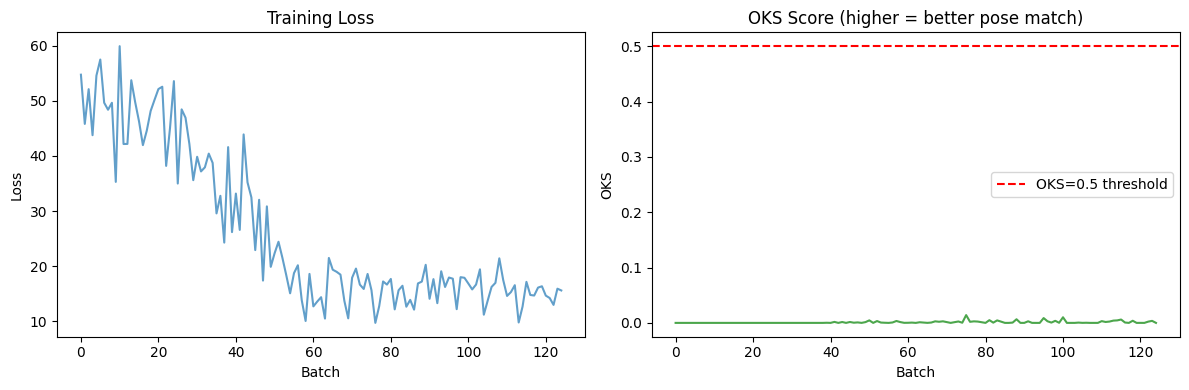

Budget used: 0.33 / 4.5 GB
Final OKS (mean last 50): 0.0021


In [16]:
# ═══ CELL 8: Evaluation + OKS summary plot ═══
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, alpha=0.7)
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Batch'); axes[0].set_ylabel('Loss')

axes[1].plot(oks_scores, color='green', alpha=0.7)
axes[1].axhline(0.5, color='red', linestyle='--', label='OKS=0.5 threshold')
axes[1].set_title('OKS Score (higher = better pose match)')
axes[1].set_xlabel('Batch'); axes[1].set_ylabel('OKS')
axes[1].legend()

plt.tight_layout()
fig.savefig(Path(DRIVE_ROOT) / 'training_curves.png', dpi=150)
plt.show()

print(f'Budget used: {(4.5 - ckpt.budget_remaining_gb()):.2f} / 4.5 GB')
print(f'Final OKS (mean last 50): {np.mean(oks_scores[-50:]):.4f}')